<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




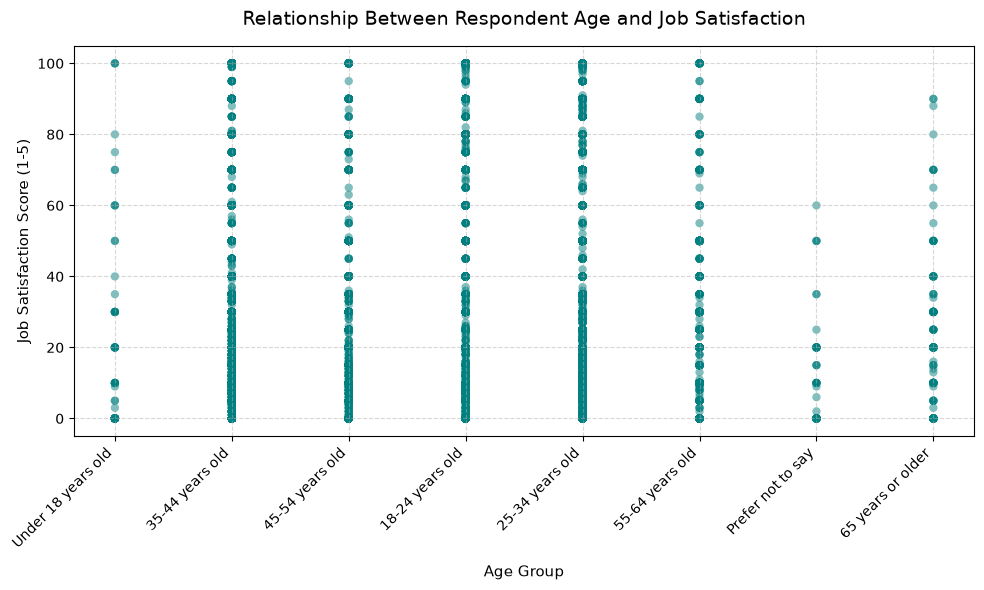

In [5]:
## Write your code here
# 1. Set up a spacious figure size
plt.figure(figsize=(10, 6))

# 2. Create the scatter plot with transparency
plt.scatter(df['Age'], df['JobSatPoints_6'], color='teal', alpha=0.5, edgecolors='none')

# 3. Add clean, descriptive labels and titles
plt.title('Relationship Between Respondent Age and Job Satisfaction', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=11, labelpad=10)
plt.ylabel('Job Satisfaction Score (1-5)', fontsize=11)

# The fix: Rotate the text to 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.5)

# 4. Display the visual cleanly with extra space at the bottom for the angled labels
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


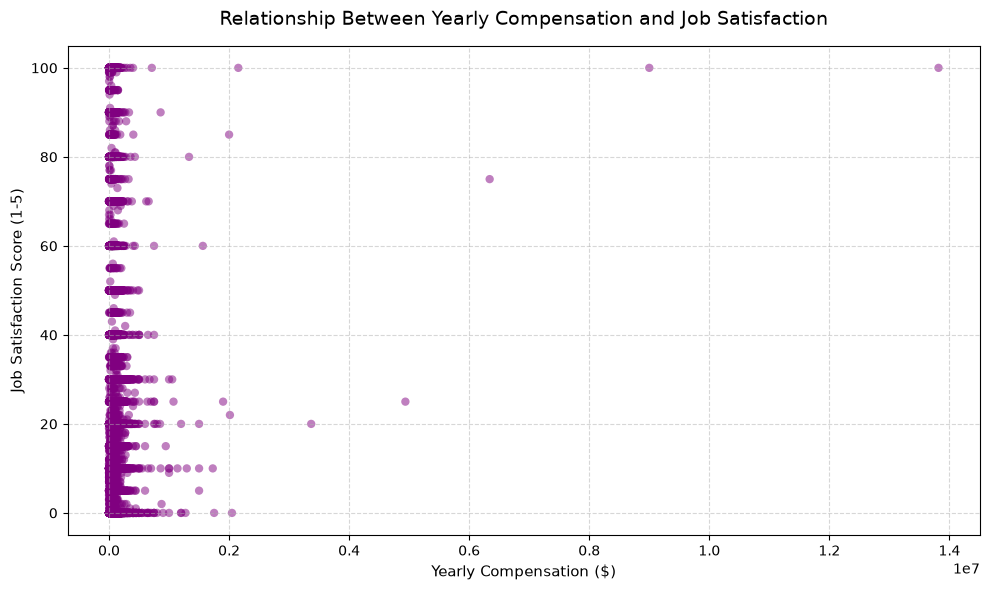

In [4]:
## Write your code here
# 1. Set up a spacious figure size
plt.figure(figsize=(10, 6))

# 2. Create the scatter plot for Compensation vs Job Satisfaction
plt.scatter(df['ConvertedCompYearly'], df['JobSatPoints_6'], color='purple', alpha=0.5, edgecolors='none')

# 3. Add clean labels and titles
plt.title('Relationship Between Yearly Compensation and Job Satisfaction', fontsize=14, pad=15)
plt.xlabel('Yearly Compensation ($)', fontsize=11)
plt.ylabel('Job Satisfaction Score (1-5)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Display the visual cleanly
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


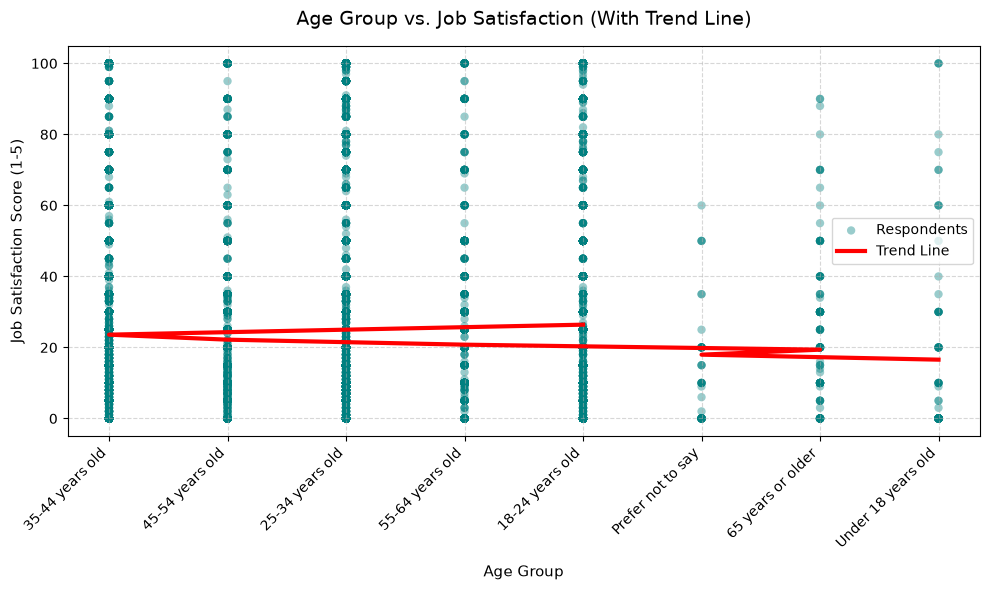

In [6]:
## Write your code here
import numpy as np

# 1. Clean missing values from our target columns
df_age_clean = df.dropna(subset=['Age', 'JobSatPoints_6'])

# 2. Convert text age groups into ordered numerical codes for line fitting
age_categories = sorted(df_age_clean['Age'].unique())
age_mapping = {cat: i for i, cat in enumerate(age_categories)}
x_numerical = df_age_clean['Age'].map(age_mapping)
y_values = df_age_clean['JobSatPoints_6']

# 3. Calculate the line of best fit (y = mx + c)
m, c = np.polyfit(x_numerical, y_values, 1)

# 4. Plot the data and the trend line
plt.figure(figsize=(10, 6))
plt.scatter(df_age_clean['Age'], y_values, color='teal', alpha=0.4, label='Respondents', edgecolors='none')
plt.plot(age_categories, m * np.arange(len(age_categories)) + c, color='red', linewidth=3, label='Trend Line')

# 5. Format labels and legend
plt.title('Age Group vs. Job Satisfaction (With Trend Line)', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=11, labelpad=10)
plt.ylabel('Job Satisfaction Score (1-5)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


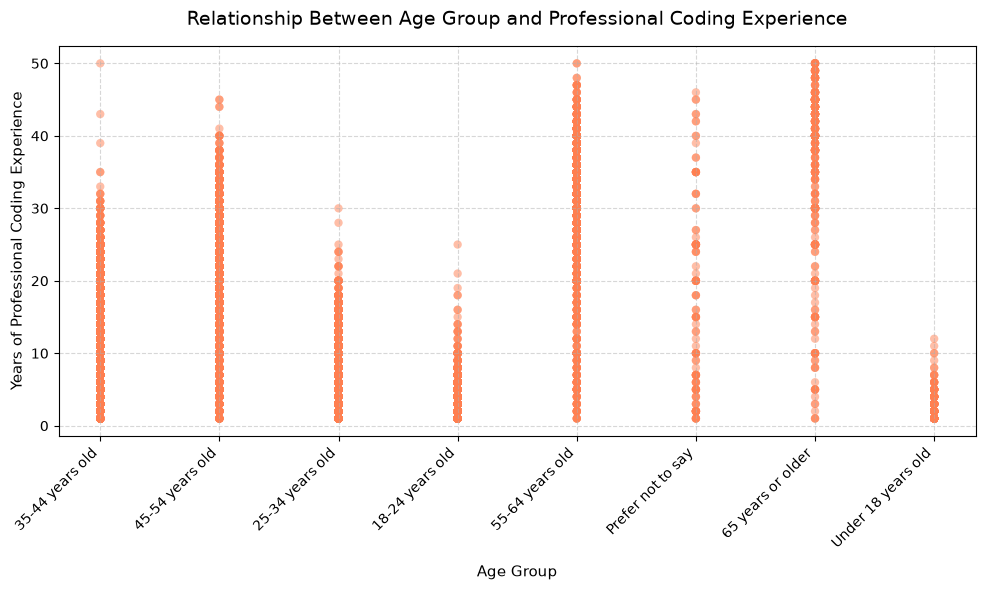

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean and convert YearsCodePro to clean numbers, ignoring errors safely
df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# 2. Drop any rows where Age or our new numerical experience is missing
df_clean = df.dropna(subset=['Age', 'YearsCodePro_num'])

# 3. Set up a spacious figure size
plt.figure(figsize=(10, 6))

# 4. Create the scatter plot using the cleaned numeric column
plt.scatter(df_clean['Age'], df_clean['YearsCodePro_num'], color='coral', alpha=0.5, edgecolors='none')

# 5. Add clean labels and titles
plt.title('Relationship Between Age Group and Professional Coding Experience', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=11, labelpad=10)
plt.ylabel('Years of Professional Coding Experience', fontsize=11)

# Rotate x-axis labels so they are beautifully legible
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


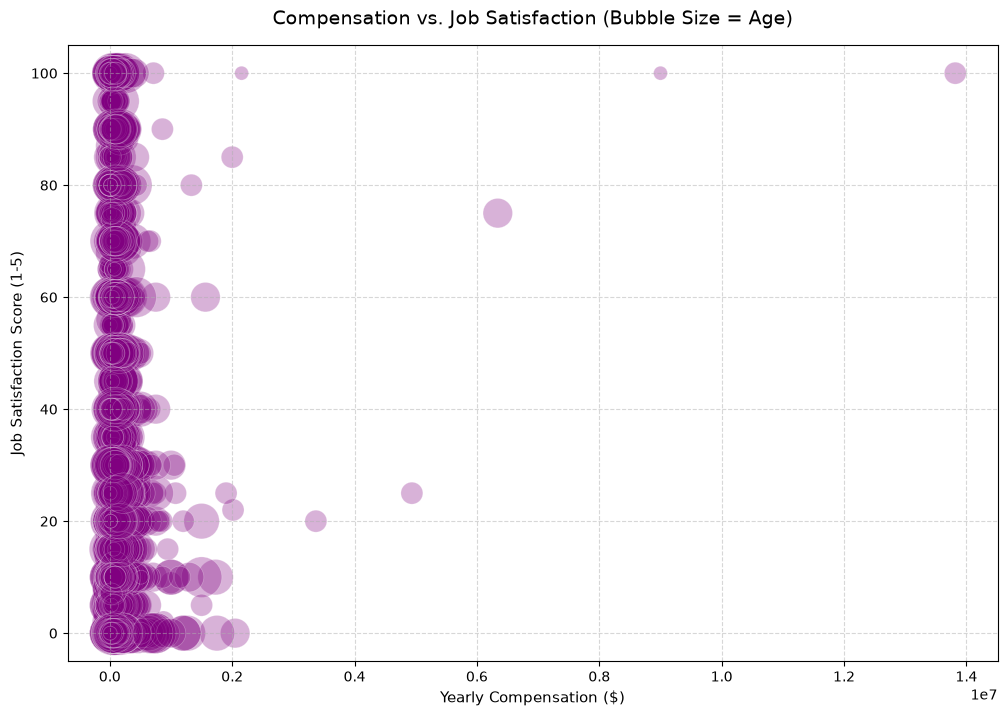

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean the data
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age'])

# 2. Map Age categories to numerical sizes for the bubbles
# We use larger values here so the bubbles are distinct and easy to see
age_mapping = {
    'Under 18 years old': 50,
    '18-24 years old': 100,
    '25-34 years old': 250,
    '35-44 years old': 450,
    '45-54 years old': 650,
    '55-64 years old': 850,
    '65 years or older': 1000
}
df_clean['Age_size'] = df_clean['Age'].map(age_mapping)

# 3. Create the bubble plot
plt.figure(figsize=(12, 8))
plt.scatter(df_clean['ConvertedCompYearly'], 
            df_clean['JobSatPoints_6'], 
            s=df_clean['Age_size'],  # Size determined by Age
            alpha=0.3, 
            color='purple',
            edgecolors='white', linewidth=0.5)

# 4. Add labels and title
plt.title('Compensation vs. Job Satisfaction (Bubble Size = Age)', fontsize=14, pad=15)
plt.xlabel('Yearly Compensation ($)', fontsize=11)
plt.ylabel('Job Satisfaction Score (1-5)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


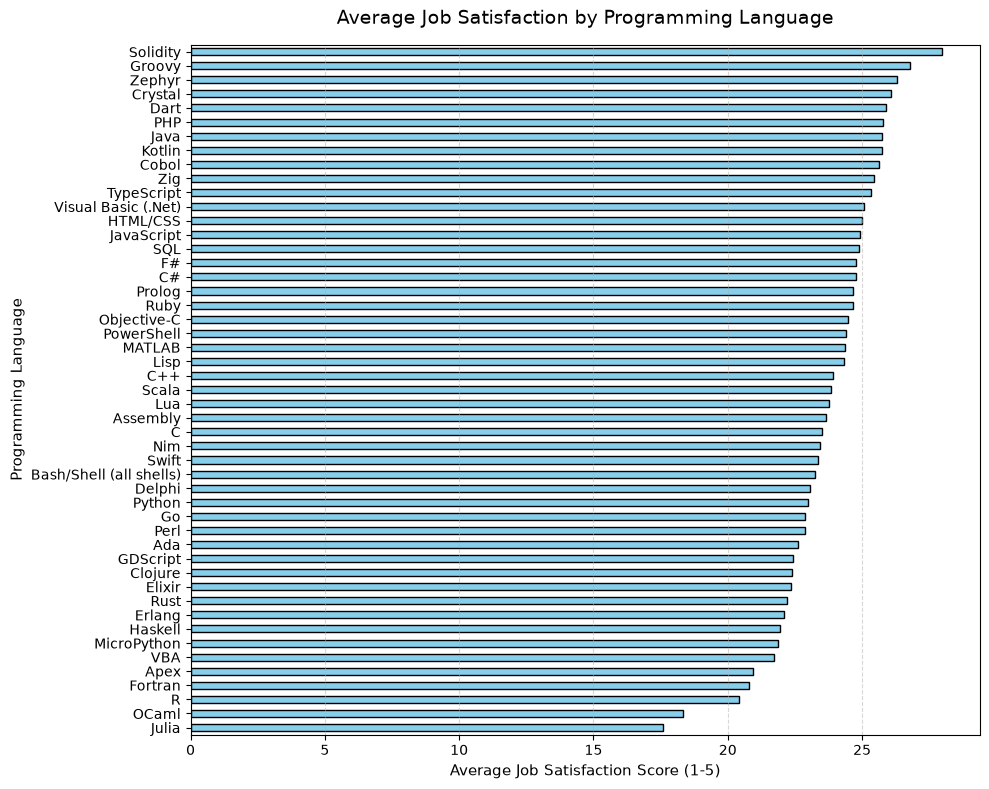

In [11]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# 1. We need to split the 'LanguageHaveWorkedWith' column 
# (since respondents often list multiple languages)
# Let's explode the list so each language gets its own row
df_lang = df.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6'])
df_lang['Language'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_lang = df_lang.explode('Language')

# 2. Calculate the average job satisfaction for each language
lang_satisfaction = df_lang.groupby('Language')['JobSatPoints_6'].mean().sort_values()

# 3. Create a horizontal bar plot (this is much cleaner than a scatter plot for categories)
plt.figure(figsize=(10, 8))
lang_satisfaction.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Average Job Satisfaction by Programming Language', fontsize=14, pad=15)
plt.xlabel('Average Job Satisfaction Score (1-5)', fontsize=11)
plt.ylabel('Programming Language', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [13]:
!pip install seaborn

/tmp/ipykernel_874/1737683309.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


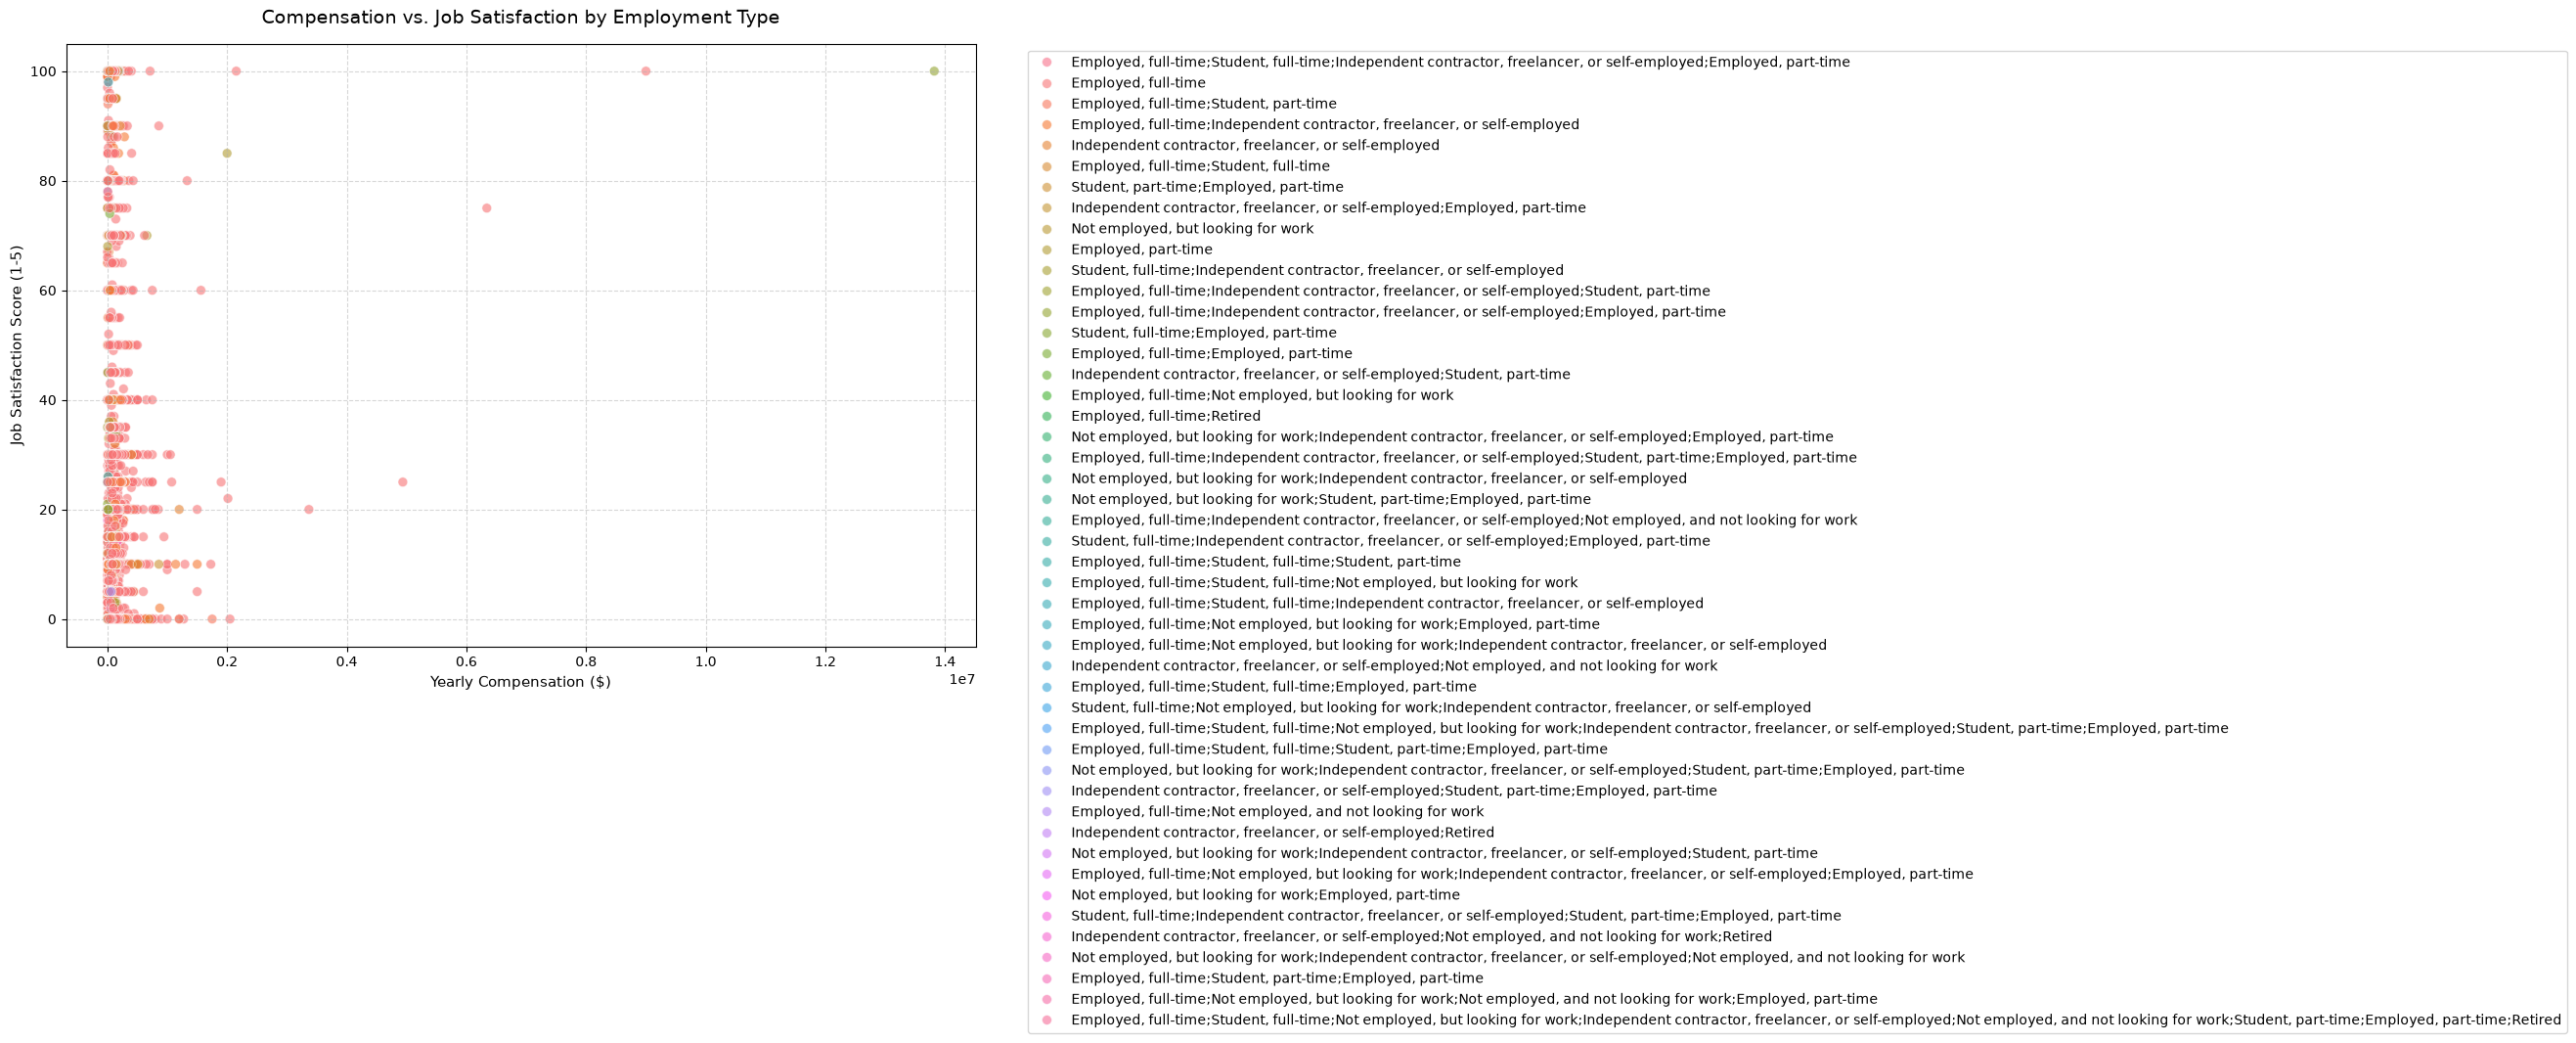

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the data to ensure we have valid numerical and categorical values
# We drop rows where Employment, compensation, or job satisfaction is missing
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Employment'])

# 2. Set up the figure size
plt.figure(figsize=(12, 8))

# 3. Create the scatter plot using Seaborn 
# 'hue' automatically assigns different colors to each unique value in 'Employment'
sns.scatterplot(
    data=df_clean, 
    x='ConvertedCompYearly', 
    y='JobSatPoints_6', 
    hue='Employment', 
    alpha=0.6, 
    s=50
)

# 4. Add titles and labels
plt.title('Compensation vs. Job Satisfaction by Employment Type', fontsize=14, pad=15)
plt.xlabel('Yearly Compensation ($)', fontsize=11)
plt.ylabel('Job Satisfaction Score (1-5)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [ ]:
## Write your code here

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
